In [24]:
import neptune as neptune
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

## Functions

In [25]:
def pivot_dict(
    activations_dict: dict, steps: list, dmodels: list, layer_num: int, module: str
):
    """
    Constructs a dictionary that maps each training step to a dictionary containing dicts: dmodel: values_list

    Parameters:
    - activations_dict (dict): The dictionary containing the activation data from get_activations().
    - steps (list): A list of training steps to consider.
    - dmodels (list): A list of 'dmodel' values to include in the output.
    - layer_num (int): The specific layer (block) number to extract data from.
    - module (str): 'FF' or 'attn', specifying which module to extract data from.

    Returns:
    - result_dict (dict): A dictionary with structure {<step>: {dmodel: [val1, val2, ...]}}
    """
    result_dict = {}

    for step in steps:
        result_dict[step] = {}

        for run_id, run_data in activations_dict.items():
            dmodel = run_data.get("dmodel")
            if dmodel in dmodels:
                layer_data = run_data.get(layer_num)
                if dmodel not in result_dict[step].keys():
                    result_dict[step][dmodel] = []
                if layer_data:
                    module_data = layer_data.get(module)
                    if module_data is not None and not module_data.empty:
                        # Filter the DataFrame for the specific step
                        step_data = module_data[module_data["step"] == step]
                        if not step_data.empty:
                            value = step_data["value"].values[0]
                            result_dict[step][dmodel].append(value)
                        else:
                            print(
                                f"No data at step {step} for run {run_id}, dmodel {dmodel}, layer {layer_num}, module {module}."
                            )
                    else:
                        print(
                            f"No module data for run {run_id}, dmodel {dmodel}, layer {layer_num}, module {module}."
                        )
                else:
                    print(
                        f"No layer data for run {run_id}, dmodel {dmodel}, layer {layer_num}."
                    )
            else:
                print(
                    f"dmodel {dmodel} from run {run_id} not in specified dmodels list."
                )

    return result_dict


def get_steps_from_first_run(activations_dict):
    """
    Returns all the 'step' values from the first run in activations_dict.

    Parameters:
    - activations_dict (dict): The dictionary containing the activation data from get_activations().

    Returns:
    - steps_list (list): A sorted list of unique 'step' values from the first run.
    """
    # Get the first run_id in the activations_dict
    first_run_id = next(iter(activations_dict))
    first_run_data = activations_dict[first_run_id]

    # Initialize an empty set to collect unique steps
    steps_set = set()

    # Exclude the 'dmodel' key and focus on block numbers
    block_keys = [key for key in first_run_data.keys() if isinstance(key, int)]

    # Iterate over each block in the first run
    for block_num in block_keys:
        block_data = first_run_data[block_num]
        # Iterate over the modules 'attn' and 'FF'
        for module in ["attn", "FF"]:
            module_data = block_data.get(module)
            if module_data is not None and not module_data.empty:
                # Add the 'step' values to the set
                steps = module_data["step"].tolist()
                steps_set.update(steps)
            else:
                print(
                    f"Module data missing or empty for block {block_num}, module {module}."
                )

    # Convert the set to a sorted list
    steps_list = sorted(steps_set)
    return steps_list


def plot_module(pivoted_dict, module_keyword, layer_num, step_interval=100):
    """
    Plots the activation values of a specific module in a specific layer across different model widths (dmodels) over training steps.
    The x-axis is set to logarithmic scale, and x-ticks match the dmodel values.

    Parameters:
    - pivoted_dict (dict): The dictionary returned by pivot_dict(), structured as {<step>: {dmodel: [val1, val2, ...]}}.
    - module_keyword (str): 'FF' or 'attn', specifying which module to plot.
    - layer_num (int): The specific layer (block) number to plot.

    Returns:
    - None
    """

    # Initialize the plot
    plt.figure(figsize=(10, 6))

    # Collect all unique dmodel values across steps for setting x-ticks
    all_dmodels = set()
    for data in pivoted_dict.values():
        all_dmodels.update(data.keys())
    all_dmodels = sorted(all_dmodels)

    # Iterate over each training step in the pivoted dictionary
    for step, data in pivoted_dict.items():
        if step % step_interval == 0:
            dmodels = np.array(list(data.keys()))
            # Sort the data based on dmodels for consistent plotting
            sorted_dmodels = np.sort(dmodels)
            sorted_values = []
            for dmodel in sorted_dmodels:
                val = np.array(data[dmodel]).mean()
                sorted_values.append(val)
            sorted_values = np.array(sorted_values)
            plt.plot(
                sorted_dmodels, sorted_values, marker="o", label=f"Step {int(step)}"
            )

    plt.xlabel("Model Width (dmodel)")
    plt.ylabel(f"Mean Activation Value ({module_keyword})")
    plt.title(f"Activation of {module_keyword} in Layer {layer_num}")
    plt.legend()
    plt.grid(True, which="both", ls="--", linewidth=0.5)

    # Set x-axis to logarithmic scale
    plt.xscale("log")
    plt.yscale("log")

    # Set x-ticks to match dmodel values
    plt.xticks(all_dmodels, labels=[str(dm) for dm in all_dmodels])

    plt.show()


def plot_module_grid(
    pivoted_dict, module_keyword, layer_num, step_interval=100, fig=None, ax=None
):
    """
    Plots the activation values of a specific module in a specific layer across different model widths (dmodels)
    over training steps. The x-axis is set to a logarithmic scale, and x-ticks match the dmodel values.

    Parameters:
    - pivoted_dict (dict): The dictionary returned by pivot_dict(), structured as {<step>: {dmodel: [val1, val2, ...]}}.
    - module_keyword (str): 'FF' or 'attn', specifying which module to plot.
    - layer_num (int): The specific layer (block) number to plot.
    - step_interval (int): Interval at which to sample steps for plotting.
    - fig (matplotlib.figure.Figure, optional): Figure object to plot on. If None, a new figure is created.
    - ax (matplotlib.axes.Axes, optional): Axes object to plot on. If None, a new axes is created.

    Returns:
    - fig (matplotlib.figure.Figure): The figure object.
    - ax (matplotlib.axes.Axes): The axes object for the plot.
    """

    if ax is None or fig is None:
        fig, ax = plt.subplots(figsize=(10, 6))

    # Collect all unique dmodel values across steps for setting x-ticks
    all_dmodels = set()
    for data in pivoted_dict.values():
        all_dmodels.update(data.keys())
    all_dmodels = sorted(all_dmodels)

    # Iterate over each training step in the pivoted dictionary
    for step, data in pivoted_dict.items():
        if step % step_interval == 0:
            dmodels = np.array(list(data.keys()))
            # Sort the data based on dmodels for consistent plotting
            sorted_dmodels = np.sort(dmodels)
            sorted_values = []
            for dmodel in sorted_dmodels:
                val = np.array(data[dmodel]).mean()
                sorted_values.append(val)
            sorted_values = np.array(sorted_values)
            ax.plot(
                sorted_dmodels, sorted_values, marker="o", label=f"Step {int(step)}"
            )

    ax.set_xlabel("Model Width (dmodel)")
    ax.set_ylabel(f"Mean Activation Value ({module_keyword})")
    ax.set_title(f"Activation of {module_keyword} in Layer {layer_num}")
    ax.legend()
    ax.grid(True, which="both", ls="--", linewidth=0.5)

    # Set x-axis to logarithmic scale
    ax.set_xscale("log")
    ax.set_yscale("log")

    # Set x-ticks to match dmodel values
    ax.set_xticks(all_dmodels)
    ax.set_xticklabels([str(dm) for dm in all_dmodels])

    fig.tight_layout()
    return fig, ax


def plot_multiple_modules(
    activations_dict,
    module_keywords,
    layer_nums,
    dmodels,
    step_interval=100,
    figsize=(15, 10),
    subplots=None,
    average_blocks=False,
):
    """
    Creates a grid of subplots, each plotting the activation values for a specified module and layer combination.
    Uses the plot_module function for each combination of module_keyword and layer_num.

    Parameters:
    - module_keywords (list of str): List of module keywords (e.g., ['FF', 'attn']).
    - layer_nums (list of int): List of layer numbers to plot.
    - step_interval (int): Interval at which to sample steps for plotting.
    - figsize (tuple): Size of the figure.

    Returns:
    - None (just shows the plot)
    """

    # Determine the number of rows and columns in the grid
    n_rows = len(module_keywords)
    if average_blocks:
        n_cols = 1
    else:
        n_cols = len(layer_nums)
    steps = get_steps_from_first_run(activations_dict)

    if subplots is None:
        fig, axs = plt.subplots(n_rows, n_cols, figsize=figsize, squeeze=False)
    else:
        fig, axs, i_start, j_start = subplots

    for i, mk in enumerate(module_keywords):
        pivot_dict_aggregate = None
        for j, ln in enumerate(layer_nums):
            pivoted_dict = pivot_dict(
                activations_dict=activations_dict,
                steps=steps,
                dmodels=dmodels,
                layer_num=ln,
                module=mk,
            )
            if not average_blocks:
                plot_module_grid(
                    pivoted_dict=pivoted_dict,
                    module_keyword=mk,
                    layer_num=ln,
                    step_interval=step_interval,
                    fig=fig,
                    ax=axs[i_start + i, j_start + j],
                )
            else:
                if pivot_dict_aggregate is None:
                    pivot_dict_aggregate = pivoted_dict
                else:
                    for step, dmodels_dict in pivoted_dict.items():
                        for dmodel, vals_list in dmodels_dict.items():
                            pivot_dict_aggregate[step][dmodel] = np.array(pivot_dict_aggregate[step][dmodel]) + np.array(vals_list)
                # Use the plot_module function to plot on the given Axes object

        if average_blocks:
            for step, dmodels_dict in pivoted_dict.items():
                for dmodel, vals_list in dmodels_dict.items():
                    pivot_dict_aggregate[step][dmodel] = list(np.array(vals_list) / len(layer_nums))
            plot_module_grid(
                pivoted_dict=pivot_dict_aggregate,
                module_keyword=mk,
                layer_num=ln,
                step_interval=step_interval,
                fig=fig,
                ax=axs[i_start + i, j_start],
            )

    if subplots is None:
        plt.show()


def plot_loss_vs_lr(runs_table, ylim=None, title=None, figsize=(10, 6), ax=None, main_varible="job_config/common/dmodel", ax_labels_font=12, tick_font=12, title_font=12):
    """
    For each model width in the runs table, plots a line where the y-axis is the final loss value
    and the x-axis is the learning rate (lr). Uses different markers for finished vs running runs.

    Parameters:
    - runs_table (pd.DataFrame): The DataFrame returned by get_neptune_table(), containing run information.
    - ylim (tuple): Y-axis limits
    - title (str): Plot title
    - figsize (tuple): Figure size
    - ax (matplotlib axis): Axis to plot on
    - main_varible (str): Main variable column name
    - ax_labels_font (int): Font size for axis labels
    - tick_font (int): Font size for ticks
    - title_font (int): Font size for title

    Returns:
    - None
    """
    color_dict = {
        1: "#1f78b4",    # Blue
        2: "#33a02c",    # Green
        4: "#e31a1c",    # Red
        8: "#ff7f00",    # Orange
        16: "#6a3d9a",   # Purple
        32: "#a65628",     # Brown
        64: "#000000",   # Black
        
        # Main range - using ColorBrewer Set1 + extensions
        128: "#1f78b4",    # Blue
        256: "#33a02c",    # Green
        512: "#e31a1c",    # Red
        768: "#ff7f00",    # Orange
        1024: "#6a3d9a",   # Purple
        1536: "#a65628",     # Brown
        2048: "#000000",   # Black
    }

    # Ensure required columns are present in runs_table
    required_columns = ["sys/id", main_varible, "learning_rate", "job_config/trainer/n_steps", "step"]
    for col in required_columns:
        if col not in runs_table.columns:
            raise ValueError(
                f"Column '{col}' is missing from runs_table. Please include it in the 'columns' parameter when calling get_neptune_table()."
            )

    # Check for required columns to determine completion status
    required_status_columns = ["job_config/trainer/n_steps", "step"]
    has_completion_info = all(col in runs_table.columns for col in required_status_columns)
    
    if not has_completion_info:
        raise ValueError(
            f"Columns 'job_config/trainer/n_steps' and 'step' are required to determine run completion status."
        )
    
    # Get final loss values for each run
    final_loss_df = get_final_loss_values(runs_table, main_varible)

    # Remove entries with missing final loss
    final_loss_df = final_loss_df[final_loss_df["final_loss"].notnull()]
    
    # Add completion status based on comparing step with job_config/trainer/n_steps
    completion_map = {}
    for _, run_row in runs_table.iterrows():
        run_id = run_row["sys/id"]
        n_steps = run_row["job_config/trainer/n_steps"]
        current_step = run_row["step"]
        
        # Consider complete if current step equals or exceeds planned steps
        is_complete = current_step >= n_steps
        completion_map[run_id] = "complete" if is_complete else "running"
    
    final_loss_df["status"] = final_loss_df["run_id"].map(completion_map)

    final_loss_df.to_csv('final_loss_df.csv')

    # Plotting
    if ax is None:
        plt.figure(figsize=figsize)
        plot_ax = plt
    else:
        plot_ax = ax

    model_widths = sorted(final_loss_df["grid_variable"].unique())
    
    for model_width in model_widths:
        df_subset = final_loss_df[final_loss_df["grid_variable"] == model_width]
        
        # Separate finished and running runs
        finished_runs = df_subset[df_subset["status"] == "complete"]
        running_runs = df_subset[df_subset["status"] != "complete"]
        
        color = color_dict.get(model_width, None)
        
        if main_varible == "job_config/common/dmodel":
            variable_label = "Model width:"
        elif main_varible == "job_config/common/expansion_rate":
            variable_label = "Number of experts:"
        elif main_varible == "job_config/common/granularity":
            variable_label = "Granularity:"
        else:
            variable_label = main_varible
            
        label = f"{variable_label} {model_width}"
        
        # Plot finished runs with 'o' marker
        if not finished_runs.empty:
            finished_sorted = finished_runs.sort_values("lr")
            means_finished = finished_sorted.groupby("lr")["final_loss"].mean()
            lrs_finished = means_finished.index.to_numpy()
            losses_finished = means_finished.values
            
            if ax is None:
                plt.plot(lrs_finished, losses_finished, marker="o", color=color, 
                        label=label, linestyle='-')
            else:
                ax.plot(lrs_finished, losses_finished, marker="o", color=color,
                       label=label, linestyle='-')
        
        # Plot running runs with square marker
        if not running_runs.empty:
            running_sorted = running_runs.sort_values("lr")
            means_running = running_sorted.groupby("lr")["final_loss"].mean()
            lrs_running = means_running.index.to_numpy()
            losses_running = means_running.values
            
            if ax is None:
                plt.plot(lrs_running, losses_running, marker="s", color=color,
                        label=label, linestyle='--', markersize=6)
            else:
                ax.plot(lrs_running, losses_running, marker="s", color=color,
                       label=label, linestyle='--', markersize=6)

    if ax is None:
        plt.legend()
        plt.tick_params(axis='both', labelsize=tick_font)
        plt.xlabel("Learning Rate (lr)", fontsize=ax_labels_font)
        plt.ylabel("Final Loss Value", fontsize=ax_labels_font)
        if title is None:
            title = "Final Loss vs Learning Rate for Different Model Widths"
        plt.title(title, fontsize=title_font)
        plt.grid(True)
        plt.xscale("log")
        if ylim is not None:
            plt.ylim(ylim)
        plt.show()
    else:
        ax.legend()
        ax.set_xlabel("Learning Rate (lr)", fontsize=ax_labels_font)
        ax.set_ylabel("Final Loss Value", fontsize=ax_labels_font)
        ax.tick_params(axis='both', labelsize=tick_font)
        ax.set_xscale("log")
        if title is None:
            title = "Final Loss vs Learning Rate"
        ax.set_title(title, fontsize=title_font)
        ax.grid(True)
        if ylim is not None:
            ax.set_ylim(ylim)


def get_final_loss_values(runs_table, main_variable="job_config/common/dmodel"):
    """
    Fetches the final loss value for each run in the runs table.

    Parameters:
    - runs_table (pd.DataFrame): The DataFrame containing run information.

    Returns:
    - pd.DataFrame: A DataFrame with columns ['run_id', 'dmodel', 'lr', 'final_loss']
    """
    final_losses = []
    for _, run_row in runs_table.iterrows():
        run_id = run_row["sys/id"]
        model_width = run_row[main_variable]
        lr = run_row["learning_rate"]
        loss = run_row["steps/100/train/loss"]

        final_losses.append(
            {"run_id": run_id, "grid_variable": model_width, "lr": lr, "final_loss": loss}
        )

    return pd.DataFrame(final_losses)

## Neptune

In [26]:
def get_neptune_table(tags, negative_tags=None, columns=None, print_columns=False):
    """
    Fetches a Neptune runs table filtered by tags and returns it as a pandas DataFrame.

    Parameters:
    - tags (list): List of tags to filter the runs.
    - negative_tags (list, optional): List of tags to exclude from the runs.
    - columns (list, optional): Additional columns to include in the runs table.
    - print_columns (bool, optional): If True, prints all available columns.

    Returns:
    - pandas.DataFrame: The runs table with the specified filters and columns.
    """

    # Initialize the Neptune project
    project = neptune.init_project(
        project="pmtest/llm-random",
        mode="read-only",
        api_token=os.environ["NEPTUNE_API_TOKEN"],
    )

    # Fetch the runs table with the specified tags and columns
    runs_table = project.fetch_runs_table(tag=tags, columns=columns).to_pandas()

    # Ensure 'sys/tags' is a list for each run
    # print(f"runs_table: {runs_table}")
    runs_table["sys/tags"] = runs_table["sys/tags"].apply(
        lambda x: x.split(",") if isinstance(x, str) else x
    )

    # Exclude runs containing any of the negative tags
    if negative_tags:
        for neg_tag in negative_tags:
            runs_table = runs_table[
                ~runs_table["sys/tags"].apply(lambda x: neg_tag in x)
            ]

    print(f"Table downloaded\nShape: {runs_table.shape}")

    if print_columns:
        print("\n=== Available columns ===")
        for col in sorted(runs_table.columns):
            print(f"  {col}")
        print("========================\n")

    return runs_table



## Plot

In [27]:
plots_folder = 'jm/plots'
os.makedirs(plots_folder, exist_ok=True)

[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/pmtest/llm-random/
Table downloaded
Shape: (26, 756)
(26, 756)


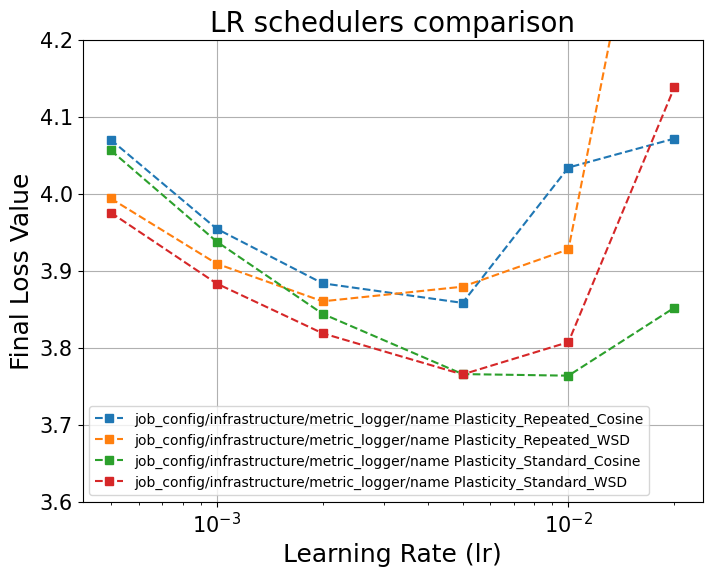

In [37]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))

# tags = ["muP_MoE", "muTransfer", "lr_grid_dense_fixed", "with_mup"]
tags = ["plasticity", "scheduler_comparison"]

df = get_neptune_table(tags)
print(df.shape)
plot_loss_vs_lr(df, (3.6, 4.2), figsize=(6, 6), title="LR schedulers comparison", ax=axes, main_varible='job_config/infrastructure/metric_logger/name', ax_labels_font=18, tick_font=15, title_font=20)

In [30]:
# Diagnostic: Check what columns are available for the new repo
tags = ["plasticity", "scheduler_comparison"]
df_diagnostic = get_neptune_table(tags, print_columns=True)
print("\n=== Sample data from first row ===")
print(df_diagnostic.iloc[0])

[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/pmtest/llm-random/
Table downloaded
Shape: (26, 756)

=== Available columns ===
  exp_lr
  job/CONDA_EXE
  job/CUDA_DEVICE_ORDER
  job/CUDA_MODULE_LOADING
  job/CUDA_VISIBLE_DEVICES
  job/HOME
  job/HOSTNAME
  job/LOCAL_RANK
  job/LOGNAME
  job/MASTER_ADDR
  job/MASTER_PORT
  job/PATH
  job/RANK
  job/SLURMD_NODENAME
  job/SLURM_ARRAY_JOB_ID
  job/SLURM_ARRAY_TASK_COUNT
  job/SLURM_ARRAY_TASK_ID
  job/SLURM_ARRAY_TASK_STEP
  job/SLURM_CLUSTER_NAME
  job/SLURM_CONF
  job/SLURM_CPUS_ON_NODE
  job/SLURM_GPUS_ON_NODE
  job/SLURM_JOBID
  job/SLURM_JOB_ACCOUNT
  job/SLURM_JOB_CPUS_PER_NODE
  job/SLURM_JOB_END_TIME
  job/SLURM_JOB_GID
  job/SLURM_JOB_GPUS
  job/SLURM_JOB_ID
  job/SLURM_JOB_NAME
  job/SLURM_JOB_PARTITION
  job/SLURM_JOB_START_TIME
  job/SLURM_JOB_UID
  job/SLURM_JOB_USER
  job/SLURM_LOCALID
  job/SLURM_MEM_PER_GPU
  job/SLURM_NODELIST
  job/SLURM_NPROCS
  job/SLURM_SUBMIT_DIR
  job/SLURM_TASKS_PER

In [31]:
import neptune as neptune
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

In [11]:
import neptune as neptune
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

In [12]:
def get_neptune_table(tags, negative_tags=None, columns=None, print_columns=False):
    """
    Fetches a Neptune runs table filtered by tags and returns it as a pandas DataFrame.

    Parameters:
    - tags (list): List of tags to filter the runs.
    - negative_tags (list, optional): List of tags to exclude from the runs.
    - columns (list, optional): Additional columns to include in the runs table.
    - print_columns (bool, optional): If True, prints all available columns.

    Returns:
    - pandas.DataFrame: The runs table with the specified filters and columns.
    """

    # Initialize the Neptune project
    project = neptune.init_project(
        project="pmtest/llm-random",
        mode="read-only",
        api_token=os.environ["NEPTUNE_API_TOKEN"],
    )

    # Fetch the runs table with the specified tags and columns
    runs_table = project.fetch_runs_table(tag=tags, columns=columns).to_pandas()

    # Ensure 'sys/tags' is a list for each run
    # print(f"runs_table: {runs_table}")
    runs_table["sys/tags"] = runs_table["sys/tags"].apply(
        lambda x: x.split(",") if isinstance(x, str) else x
    )

    # Exclude runs containing any of the negative tags
    if negative_tags:
        for neg_tag in negative_tags:
            runs_table = runs_table[
                ~runs_table["sys/tags"].apply(lambda x: neg_tag in x)
            ]

    print(f"Table downloaded\nShape: {runs_table.shape}")

    if print_columns:
        print("\n=== Available columns ===")
        for col in sorted(runs_table.columns):
            print(f"  {col}")
        print("========================\n")

    return runs_table

In [13]:
# Diagnostic: Check what columns are available for the new repo
tags = ["plasticity", "scheduler_comparison"]
df_diagnostic = get_neptune_table(tags, print_columns=True)
print("\n=== Sample data from first row ===")
print(df_diagnostic.iloc[0])

[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/pmtest/llm-random/
Table downloaded
Shape: (26, 756)

=== Available columns ===
  exp_lr
  job/CONDA_EXE
  job/CUDA_DEVICE_ORDER
  job/CUDA_MODULE_LOADING
  job/CUDA_VISIBLE_DEVICES
  job/HOME
  job/HOSTNAME
  job/LOCAL_RANK
  job/LOGNAME
  job/MASTER_ADDR
  job/MASTER_PORT
  job/PATH
  job/RANK
  job/SLURMD_NODENAME
  job/SLURM_ARRAY_JOB_ID
  job/SLURM_ARRAY_TASK_COUNT
  job/SLURM_ARRAY_TASK_ID
  job/SLURM_ARRAY_TASK_STEP
  job/SLURM_CLUSTER_NAME
  job/SLURM_CONF
  job/SLURM_CPUS_ON_NODE
  job/SLURM_GPUS_ON_NODE
  job/SLURM_JOBID
  job/SLURM_JOB_ACCOUNT
  job/SLURM_JOB_CPUS_PER_NODE
  job/SLURM_JOB_END_TIME
  job/SLURM_JOB_GID
  job/SLURM_JOB_GPUS
  job/SLURM_JOB_ID
  job/SLURM_JOB_NAME
  job/SLURM_JOB_PARTITION
  job/SLURM_JOB_START_TIME
  job/SLURM_JOB_UID
  job/SLURM_JOB_USER
  job/SLURM_LOCALID
  job/SLURM_MEM_PER_GPU
  job/SLURM_NODELIST
  job/SLURM_NPROCS
  job/SLURM_SUBMIT_DIR
  job/SLURM_TASKS_PER

In [14]:
# Check the specific columns we need
print("\n=== Key columns for plotting ===")
key_cols = ['sys/id', 'step', 'learning_rate', 'job_config/trainer/n_steps', 
            'job_config/common/dmodel', 'job_config/common/n_blocks',
            'job_config/trainer/learning_rate']

for col in key_cols:
    if col in df_diagnostic.columns:
        print(f"✓ {col}")
        print(f"  Sample value: {df_diagnostic.iloc[0][col]}")
    else:
        print(f"✗ {col} - NOT FOUND")

# Check for loss columns
print("\n=== Loss columns ===")
loss_cols = [col for col in df_diagnostic.columns if 'loss' in col.lower()]
for col in loss_cols:
    print(f"  {col}")


=== Key columns for plotting ===
✓ sys/id
  Sample value: LLMRANDOM-39309
✓ step
  Sample value: 9999.0
✓ learning_rate
  Sample value: 0.001
✓ job_config/trainer/n_steps
  Sample value: 10000
✓ job_config/common/dmodel
  Sample value: 512
✓ job_config/common/n_blocks
  Sample value: 4
✓ job_config/trainer/learning_rate
  Sample value: 0.001

=== Loss columns ===
  steps/100/train/loss
  steps/eval/loss
  steps/train/loss
  tokens/eval/loss
  tokens/train/loss


In [15]:
# Check which loss column has data
print("=== Checking loss columns ===")
print(f"steps/100/train/loss: {df_diagnostic.iloc[0]['steps/100/train/loss']}")
print(f"steps/eval/loss: {df_diagnostic.iloc[0]['steps/eval/loss']}")
print(f"steps/train/loss: {df_diagnostic.iloc[0]['steps/train/loss']}")


=== Checking loss columns ===
steps/100/train/loss: 3.93765625
steps/eval/loss: 3.94921875
steps/train/loss: 3.9453125


In [16]:
# Test the updated functions with the new column names
tags = ["plasticity", "scheduler_comparison"]
df_test = get_neptune_table(tags)

print("\n=== Testing plot_loss_vs_lr ===")
print(f"Available columns check:")
print(f"  sys/id: {'sys/id' in df_test.columns}")
print(f"  job_config/common/dmodel: {'job_config/common/dmodel' in df_test.columns}")
print(f"  learning_rate: {'learning_rate' in df_test.columns}")
print(f"  job_config/trainer/n_steps: {'job_config/trainer/n_steps' in df_test.columns}")
print(f"  step: {'step' in df_test.columns}")
print(f"  steps/100/train/loss: {'steps/100/train/loss' in df_test.columns}")

print("\n=== Sample data ===")
print(df_test[['sys/id', 'job_config/common/dmodel', 'learning_rate', 'steps/100/train/loss']].head())

[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/pmtest/llm-random/
Table downloaded
Shape: (26, 756)

=== Testing plot_loss_vs_lr ===
Available columns check:
  sys/id: True
  job_config/common/dmodel: True
  learning_rate: True
  job_config/trainer/n_steps: True
  step: True
  steps/100/train/loss: True

=== Sample data ===
            sys/id  job_config/common/dmodel  learning_rate  \
0  LLMRANDOM-39309                       512         0.0010   
1  LLMRANDOM-39308                       512         0.0005   
2  LLMRANDOM-39307                       512         0.0010   
3  LLMRANDOM-39306                       512         0.0005   
4  LLMRANDOM-39305                       512         0.0010   

   steps/100/train/loss  
0              3.937656  
1              4.056211  
2              3.883125  
3              3.975273  
4              3.954258  


ValueError: Column 'args/dmodel' is missing from runs_table. Please include it in the 'columns' parameter when calling get_neptune_table().

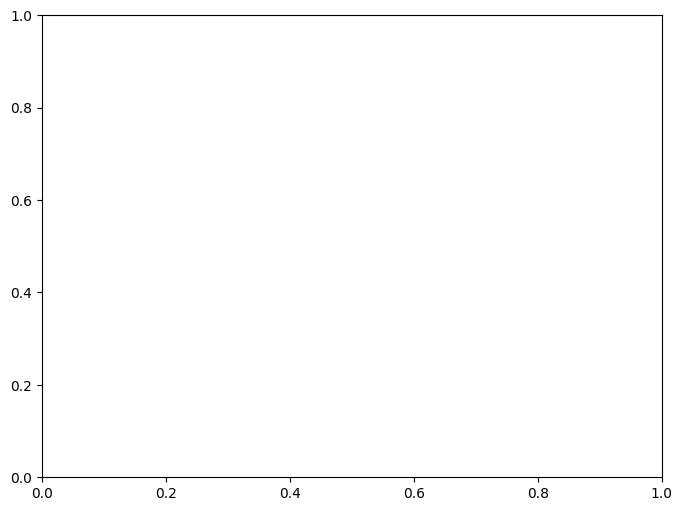

In [17]:
# Create a simple test plot
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

plot_loss_vs_lr(
    df_test, 
    ylim=(3.5, 4.5), 
    title="Test: Loss vs LR (Updated Column Names)", 
    ax=ax
)

plt.tight_layout()
plt.show()

print("\n✓ Plot generated successfully with new column names!")

In [18]:
# Reload all functions from cell-2
exec(open('/dev/stdin').read(), globals()) if False else None

# Import the updated functions by re-executing cell-2 content
%run -i -e

Exception: you must provide at least a filename.